In [9]:
import yaml
import os
import numpy as np
import pandas as pd

In [10]:
v_rel = np.sqrt(39 * 2 * 1e3 * 0.39 / 0.02)  # Relative velocity in m/s
print(f"Relative velocity (x-direction): {v_rel:.2f} m/s")

Relative velocity (x-direction): 1233.29 m/s


In [11]:
base_path = os.path.abspath("")
config_folder = os.path.join(base_path, "configs")
io_folder = os.path.join(base_path, "input-output")

os.makedirs(config_folder, exist_ok=True)
os.makedirs(io_folder, exist_ok=True)

config_file_path = os.path.join(config_folder, "model_config.yaml")
data_file_path = os.path.join(config_folder, "data.yaml")

In [12]:
config = {
    "simulation": {
        "minimalCharacteristicLength": 0.00027,
        "simulationType": "COLLISION",
        "inputSource": [data_file_path]  # Percorso assoluto a data.yaml
    },
    "inputOutput": {
        "target": [
            os.path.join(io_folder, "input.csv"), 
            os.path.join(io_folder, "input.vtu")
        ],
        "kepler": False
    },
    "resultOutput": {
        "target": [
            os.path.join(io_folder, "result.csv"), 
            os.path.join(io_folder, "result.vtu")
        ],
        "kepler": False
    }
}

data = {
    "satellites": [
        {
            "id": 1, "name": "Target", "satType": "SPACECRAFT",
            "mass": 0.39, "area": 0.01, "position": [100000, 0, 0], "velocity": [-5, 0, 0]
        },
        {
            "id": 2, "name": "Projectile", "satType": "SPACECRAFT",
            "mass": 0.02, "area": 0.0002, "position": [100000, 0, 0], "velocity": [1233.29, 0, 0]
        }
    ]
}

In [13]:
with open(config_file_path, 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=None)

with open(data_file_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False, default_flow_style=None)

In [14]:
!cd {"../../build"} && ./breakupModel {config_file_path}

[2026-04-07 15:53:13.669] [info] Running SubCollision with cardinality 1.
[2026-04-07 15:53:13.677] [debug] The simulation got 0.39 kg of input mass for fragments
[2026-04-07 15:53:13.677] [debug] The simulation produced 0.087227895379754 kg of debris
[2026-04-07 15:53:13.681] [debug] Initial mass was 0.39 kg, final mass is 0.087227895379754 kg.
[2026-04-07 15:53:13.681] [debug] Initial kinetic energy was 4.875 J, final kinetic energy is 4.8749999999632685 J. Difference is 3.673150672511838e-11 J (7.534668046023571e-10%).
[2026-04-07 15:53:13.682] [debug] Initial momentum was [-1.9500000000000002, 0, 0] kg*m/s, final momentum is [-0.14551124337706572, -0.03643850036947966, 0.027144580385159905] kg*m/s, difference is 1.8050607372972376 kg*m/s (92.56721729254718%).
[2026-04-07 15:53:13.682] [info] Running SubCollision with cardinality 2.
[2026-04-07 15:53:13.684] [debug] The simulation got 0.02 kg of input mass for fragments
[2026-04-07 15:53:13.684] [debug] The simulation produced 0.011

In [20]:
import pyvista as pv

/home/andrea/miniconda3/envs/myenv/lib/python3.8/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


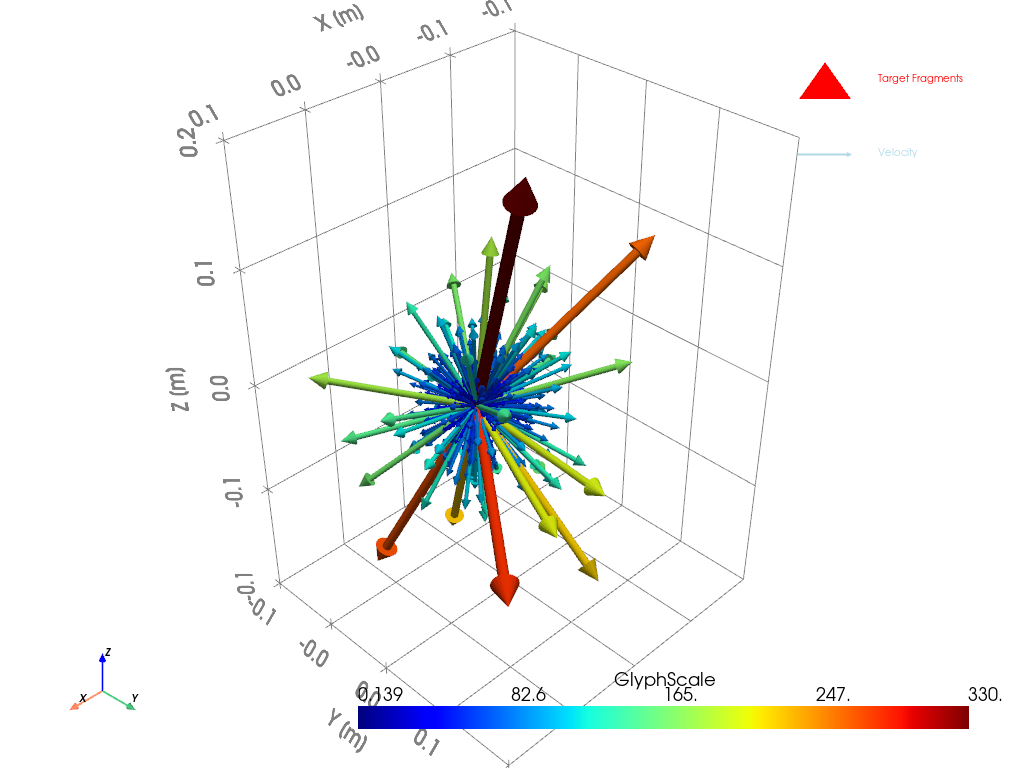

In [21]:
vtu_file = os.path.abspath("input-output/result.vtu")
mesh = pv.read(vtu_file)

ids = mesh.point_data["id"]
mask = ids < 9221
indices = np.where(mask)[0]

filtered_mesh = pv.PolyData(mesh.points[indices])


for key in mesh.point_data.keys():
    filtered_mesh.point_data[key] = mesh.point_data[key][indices]

vector_name = "velocity"
filtered_mesh.set_active_vectors(vector_name)

arrows = filtered_mesh.glyph(
    orient=vector_name,
    scale=vector_name,
    factor=0.0005,
    geom=pv.Arrow(tip_length=0.1, tip_radius=0.05, shaft_radius=0.02)
)

plotter = pv.Plotter(notebook=True)

plotter.add_mesh(
    filtered_mesh,
    color='red',
    render_points_as_spheres=True,
    point_size=10,
    label='Target Fragments'
)

plotter.add_mesh(arrows, cmap='jet', label='Velocity')
plotter.show_grid(color='gray', xtitle='X [m]', ytitle='Y [m]', ztitle='Z [m]')

plotter.add_axes()
plotter.add_legend()
plotter.show()

In [17]:
# The final kinetic energy is the sum of the kinetic energies of all fragments after the collision.
# The fragments' velocities can be found in /input-output/result.csv in the column "velocity". We can read this file and compute the kinetic energy.
output_dir = os.path.join(base_path, "input-output")
output_file = os.path.join(output_dir, "result.csv")
df_output = pd.read_csv(output_file)
input_dir = os.path.join(base_path, "input-output")
input_file = os.path.join(input_dir, "input.csv")
df_input = pd.read_csv(input_file)

# Apply the parser to the velocity column
velocities_output = df_output["Velocity [m/s]"].apply(lambda x: np.fromstring(x.strip('[]'), sep=' '))
velocities_input = df_input["Velocity [m/s]"].apply(lambda x: np.fromstring(x.strip('[]'), sep=' '))
# Convert to arrays
velocities_output = np.array(velocities_output.tolist())
velocities_input = np.array(velocities_input.tolist())

In [18]:
# Check kinetic energy conservation
masses_output = df_output["Mass [kg]"].values
kinetic_energies_output = 0.5 * masses_output * np.sum(velocities_output**2, axis=1)
total_kinetic_energy_output = np.sum(kinetic_energies_output)

masses_input = df_input["Mass [kg]"].values
kinetic_energies_input = 0.5 * masses_input * np.sum(velocities_input**2, axis=1)
total_kinetic_energy_input = np.sum(kinetic_energies_input)

print(f"Total kinetic energy before collision: {total_kinetic_energy_input:.2f} J")
print(f"Total kinetic energy after collision: {total_kinetic_energy_output:.2f} J")
# Difference in percentage
energy_difference = np.abs(total_kinetic_energy_output - total_kinetic_energy_input) / total_kinetic_energy_input * 100
print(f"Difference in kinetic energy: {energy_difference:.2f}%")

Total kinetic energy before collision: 15214.92 J
Total kinetic energy after collision: 15214.92 J
Difference in kinetic energy: 0.00%


In [19]:
# Same for momentum conservation
momentum_output = np.sum(masses_output[:, np.newaxis] * velocities_output, axis=0)
momentum_input = np.sum(masses_input[:, np.newaxis] * velocities_input, axis=0)
print(f"Total momentum before collision: {momentum_input} kg*m/s")
print(f"Total momentum after collision: {momentum_output} kg*m/s")
momentum_difference = np.linalg.norm(momentum_output - momentum_input) / np.linalg.norm(momentum_input) * 100
print(f"Difference in momentum: {momentum_difference:.2f}%")

Total momentum before collision: [22.7158  0.      0.    ] kg*m/s
Total momentum after collision: [15.38487752 -0.45699628  0.36047863] kg*m/s
Difference in momentum: 32.37%


In [22]:
import matplotlib.pyplot as plt

In [23]:
import seaborn as sns

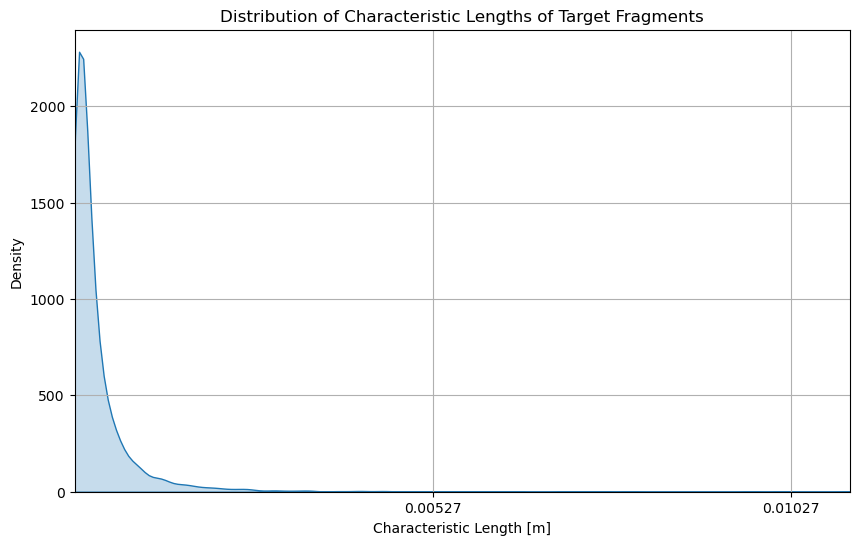

In [32]:
# Distribution of fragments' Characteristic Lengths, considering just Target fragments (id < 9221)
target_fragments = df_output[df_output["ID"] < 9221]
characteristic_lengths = target_fragments["Characteristic Length [m]"]

plt.figure(figsize=(10, 6))
# X-axis ends where there are no more fragments
plt.xticks(np.round(np.arange(characteristic_lengths.min(), characteristic_lengths.max(), 0.005), 7))
sns.kdeplot(characteristic_lengths, fill=True)
plt.title("Distribution of Characteristic Lengths of Target Fragments")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Density")
plt.xlim(characteristic_lengths.min(), characteristic_lengths.max())
plt.grid()
plt.show()

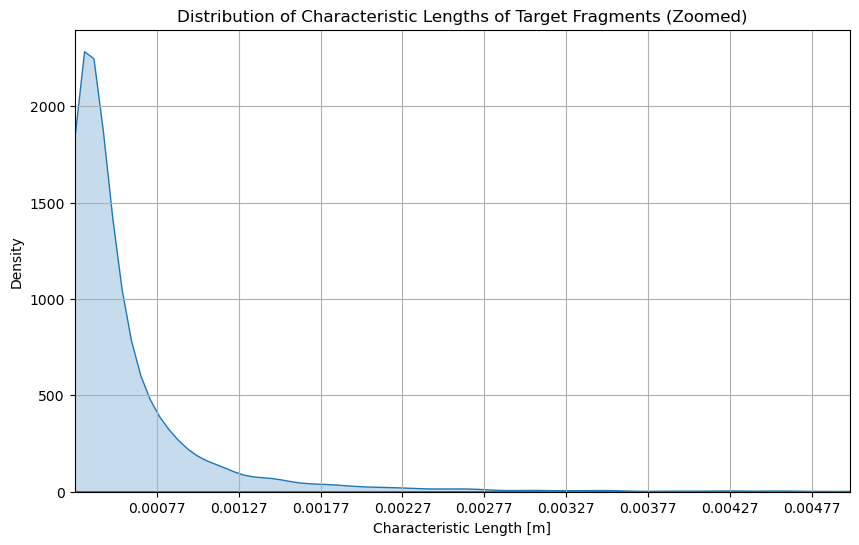

In [33]:
# Zooming in the range of characteristic lengths between 0 and 0.005 m with 7 decimal places for x ticks
plt.figure(figsize=(10, 6))
plt.xticks(np.round(np.arange(characteristic_lengths.min(), 0.0051, 0.0005), 7))
sns.kdeplot(characteristic_lengths, fill=True)
plt.title("Distribution of Characteristic Lengths of Target Fragments (Zoomed)")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Density")
plt.xlim(characteristic_lengths.min(), 0.005)
plt.grid()
plt.show()

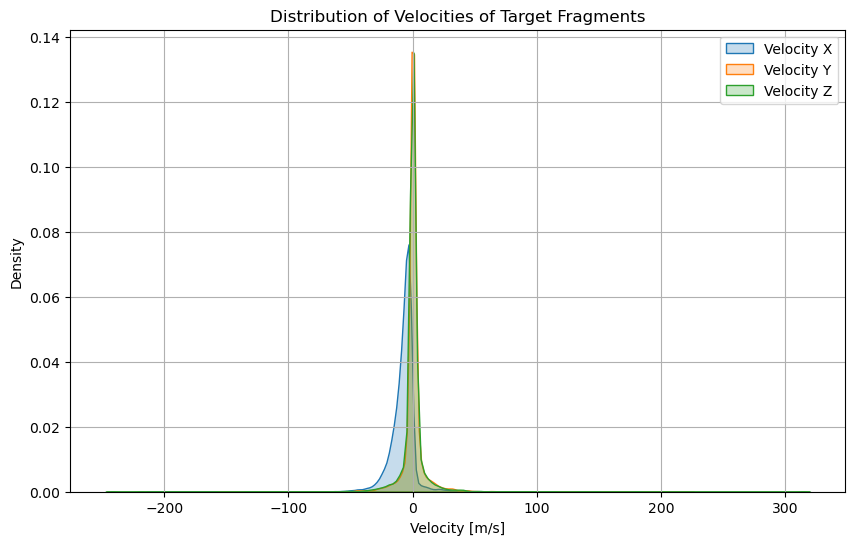

In [35]:
# Dossier of fragments' velocities, considering just Target fragments (id < 9221)
target_velocities = velocities_output[df_output["ID"] < 9221]
plt.figure(figsize=(10, 6))
sns.kdeplot(target_velocities[:, 0], fill=True, label='Velocity X')
sns.kdeplot(target_velocities[:, 1], fill=True, label='Velocity Y')
sns.kdeplot(target_velocities[:, 2], fill=True, label='Velocity Z')
plt.title("Distribution of Velocities of Target Fragments")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

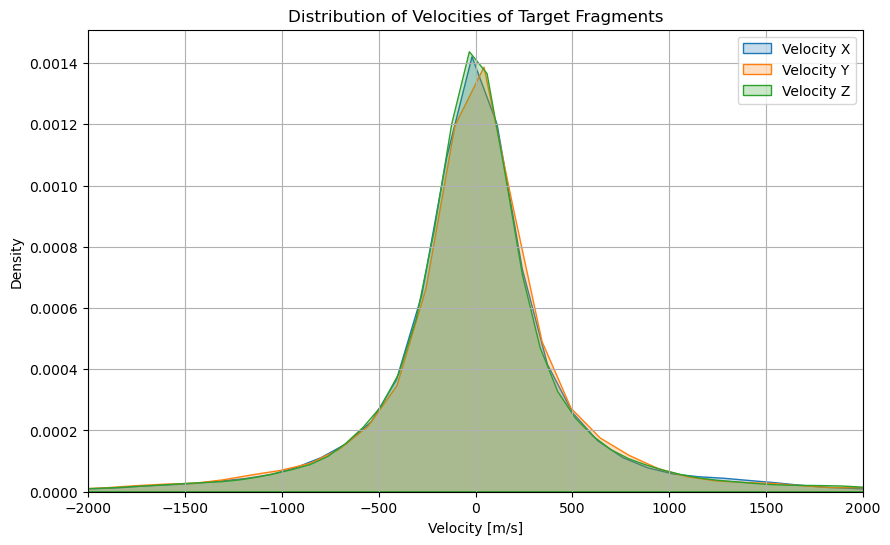

In [ ]:
# Dossier of fragments' velocities, considering just Target fragments (id < 8163)
velocities_array = np.array(velocities.tolist())
target_velocities = velocities_array[df["ID"] < 8163]
plt.figure(figsize=(10, 6))
sns.kdeplot(target_velocities[:, 0], fill=True, label='Velocity X')
sns.kdeplot(target_velocities[:, 1], fill=True, label='Velocity Y')
sns.kdeplot(target_velocities[:, 2], fill=True, label='Velocity Z')
plt.xlim(-2000, +2000)
plt.title("Distribution of Velocities of Target Fragments")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

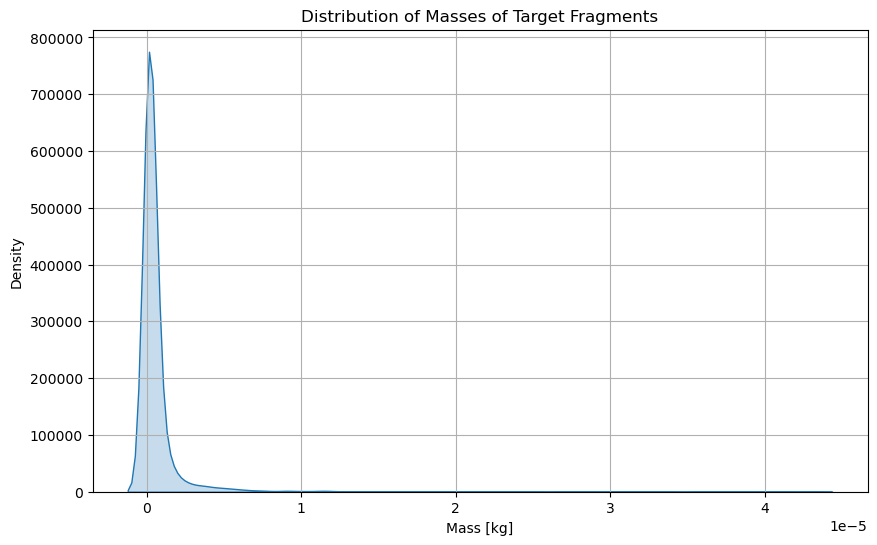

In [36]:
# Distribution of fragments' masses, considering just Target fragments (id < 8163)
target_masses = target_fragments["Mass [kg]"]
plt.figure(figsize=(10, 6))
sns.kdeplot(target_masses, fill=True)
plt.title("Distribution of Masses of Target Fragments")
plt.xlabel("Mass [kg]")
plt.ylabel("Density")
plt.grid()
plt.show()  

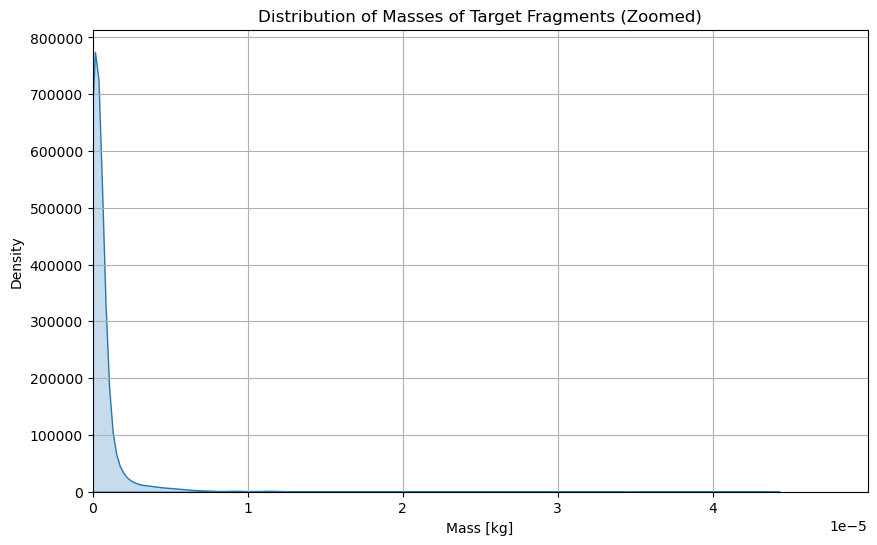

In [37]:
# Zoom in and consider 7 decimal places for x ticks
plt.figure(figsize=(10, 6))
plt.xlim(target_masses.min(), 0.00005)
plt.xticks(np.round(np.arange(target_masses.min(), 0.00005, 0.00001), 7))
sns.kdeplot(target_masses, fill=True)
plt.title("Distribution of Masses of Target Fragments (Zoomed)")
plt.xlabel("Mass [kg]")
plt.ylabel("Density")
plt.grid()
plt.show()

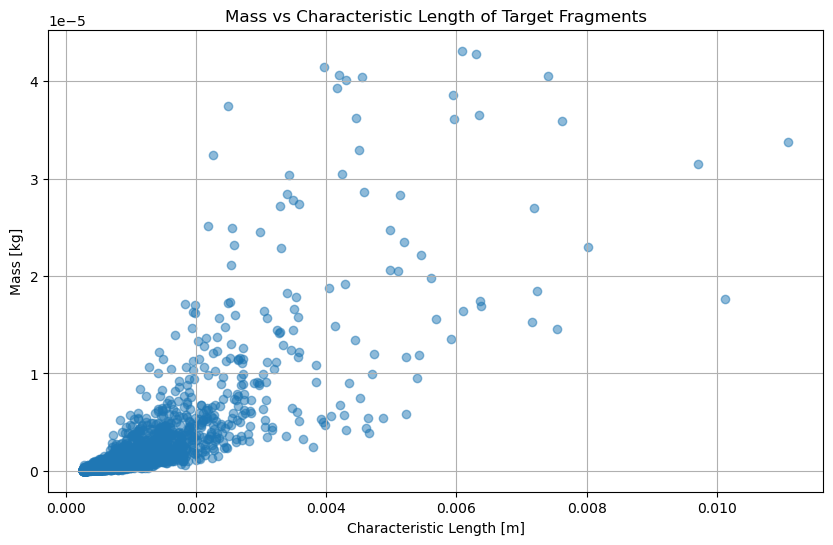

In [38]:
# Point cloud of mass vs characteristic length for Target fragments (id < 8163)
plt.figure(figsize=(10, 6))
plt.scatter(target_fragments["Characteristic Length [m]"], target_fragments["Mass [kg]"], alpha=0.5)
plt.title("Mass vs Characteristic Length of Target Fragments")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Mass [kg]")
plt.grid()
plt.show()

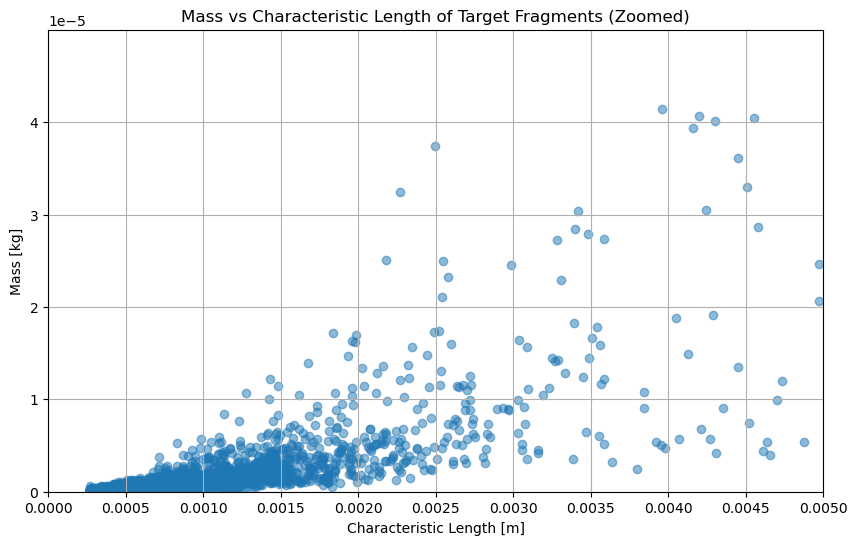

In [39]:
# Zoomed in for Char Length between 0 and 0.005 m and Mass between 0 and 0.00005 kg, with 7 decimal places for x ticks
plt.figure(figsize=(10, 6))
plt.xlim(0, 0.005)
plt.ylim(0, 0.00005)
plt.xticks(np.round(np.arange(0, 0.0051, 0.0005), 7))
plt.yticks(np.round(np.arange(0, 0.00005, 0.00001), 7))
plt.scatter(target_fragments["Characteristic Length [m]"], target_fragments["Mass [kg]"], alpha=0.5)
plt.title("Mass vs Characteristic Length of Target Fragments (Zoomed)")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Mass [kg]")
plt.grid()
plt.show()

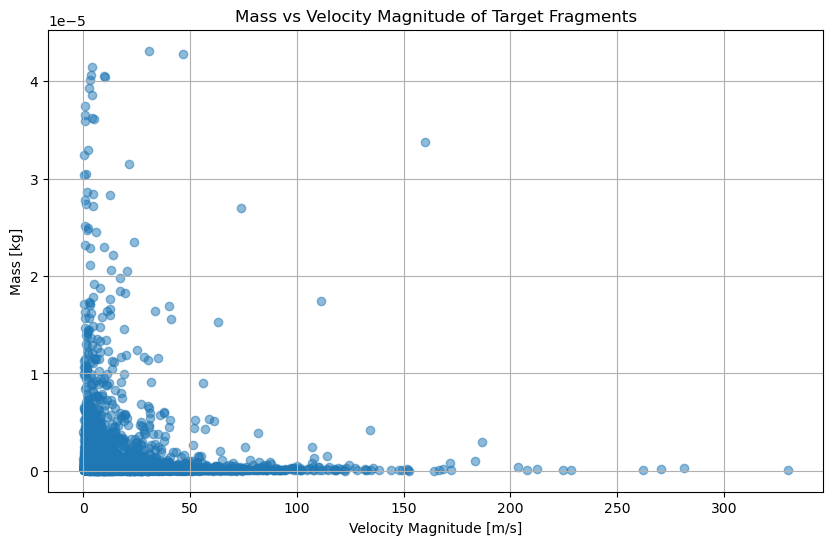

In [40]:
# Point cloud of velocity magnitude vs mass for Target fragments (id < 8163)
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
plt.figure(figsize=(10, 6))
plt.scatter(velocity_magnitudes, target_fragments["Mass [kg]"], alpha=0.5)
plt.title("Mass vs Velocity Magnitude of Target Fragments")
plt.xlabel("Velocity Magnitude [m/s]")
plt.ylabel("Mass [kg]")
plt.grid()
plt.show()

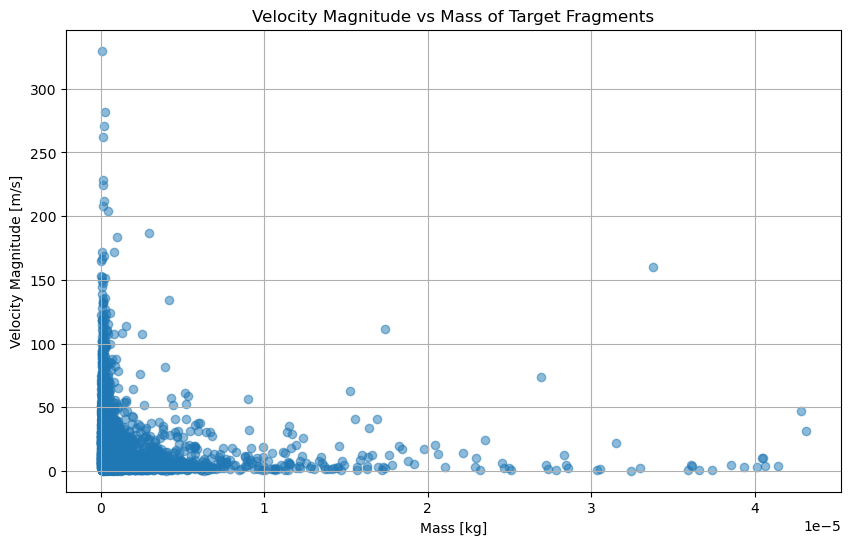

In [41]:
# Let's try the opposite, velocity magnitude vs mass for Target fragments (id < 8163)
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
plt.figure(figsize=(10, 6))
plt.scatter(target_fragments["Mass [kg]"], velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Mass of Target Fragments")
plt.xlabel("Mass [kg]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

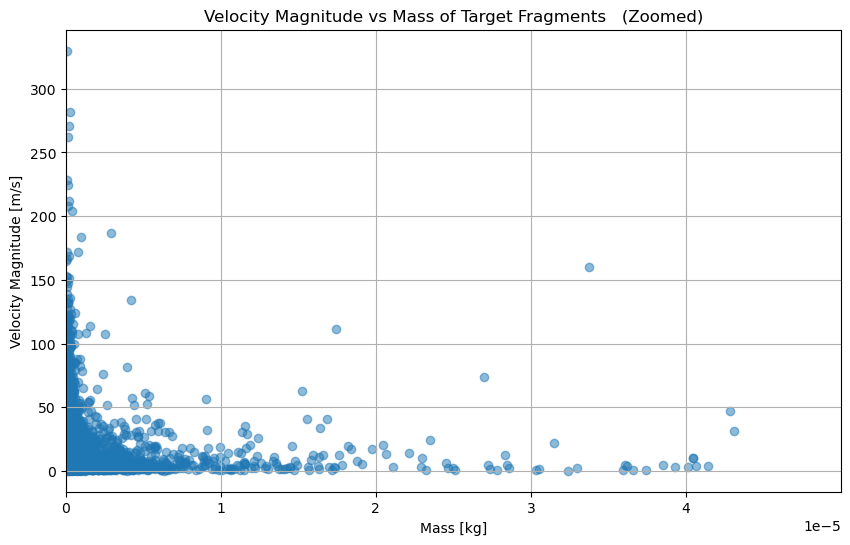

In [42]:
# Zoomed in for mass between 0 and 0.00005 kg, with 7 decimal places for x ticks
plt.figure(figsize=(10, 6))
plt.xlim(0, 0.00005)
plt.xticks(np.round(np.arange(0, 0.00005, 0.00001), 7))
plt.scatter(target_fragments["Mass [kg]"], velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Mass of Target Fragments   (Zoomed)")
plt.xlabel("Mass [kg]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

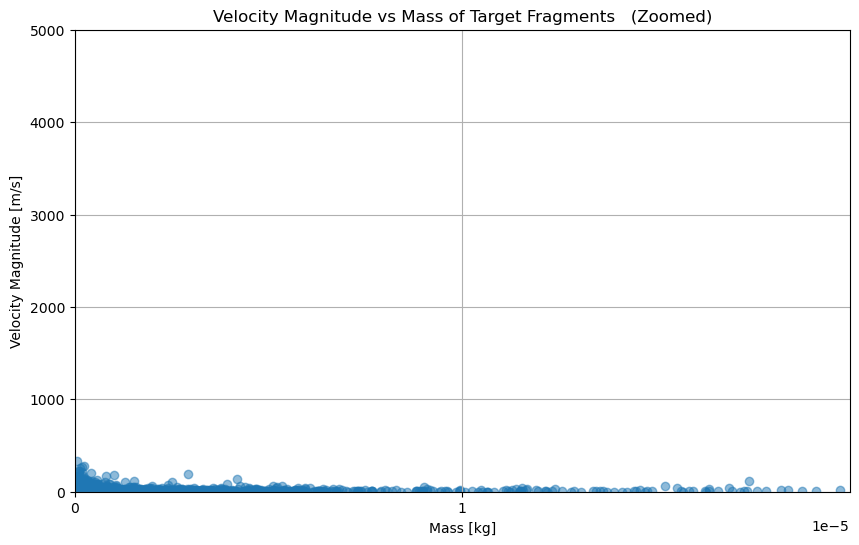

In [43]:
# Zoom for mass between 0 and 0.00002 kg, with 7 decimal places for x ticks, and velocity magnitude between 0 and 5000 m/s
plt.figure(figsize=(10, 6))
plt.xlim(0, 0.00002)
plt.ylim(0, 5000)
plt.xticks(np.round(np.arange(0, 0.00002, 0.00001), 7))
plt.yticks(np.round(np.arange(0, 5001, 1000), 7))
plt.scatter(target_fragments["Mass [kg]"], velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Mass of Target Fragments   (Zoomed)")
plt.xlabel("Mass [kg]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

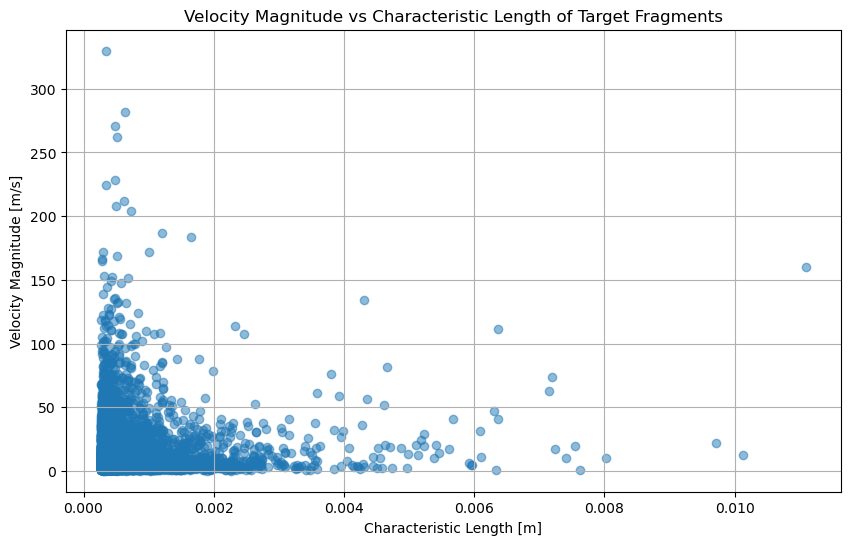

In [44]:
# Point cloud of velocity magnitude vs characteristic length for Target fragments (id < 8163)
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
plt.figure(figsize=(10, 6))
plt.scatter(target_fragments["Characteristic Length [m]"], velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Characteristic Length of Target Fragments")
plt.xlabel("Characteristic Length [m]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

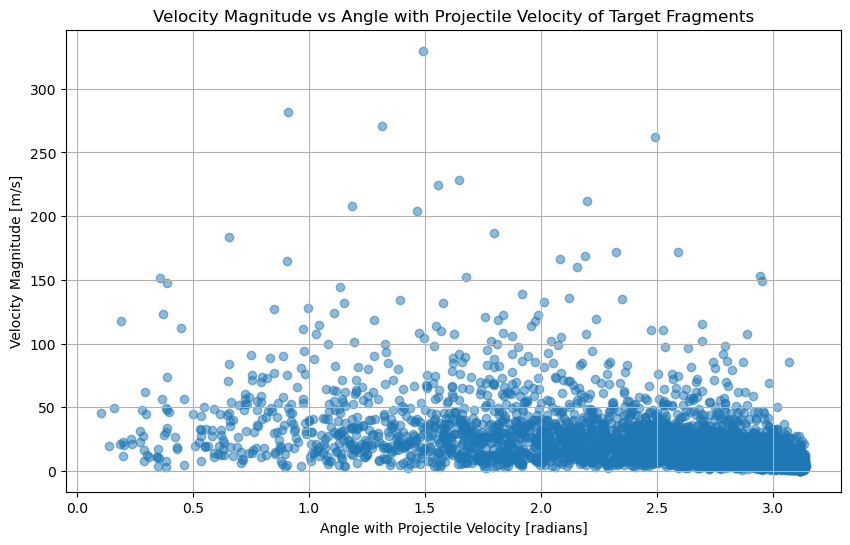

In [45]:
# Point cloud of fragments' velocity magnitude vs the angle between their velocity and the projectile's velocity, for Target fragments (id < 8163)
projectile_velocity = np.array([v_rel, 0, 0])
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
dot_products = np.einsum('ij,j->i', target_velocities, projectile_velocity)
projectile_speed = np.linalg.norm(projectile_velocity)
angles = np.arccos(dot_products / (velocity_magnitudes * projectile_speed + 1e-10))
plt.figure(figsize=(10, 6))
plt.scatter(angles, velocity_magnitudes, alpha=0.5)
plt.title("Velocity Magnitude vs Angle with Projectile Velocity of Target Fragments")
plt.xlabel("Angle with Projectile Velocity [radians]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()

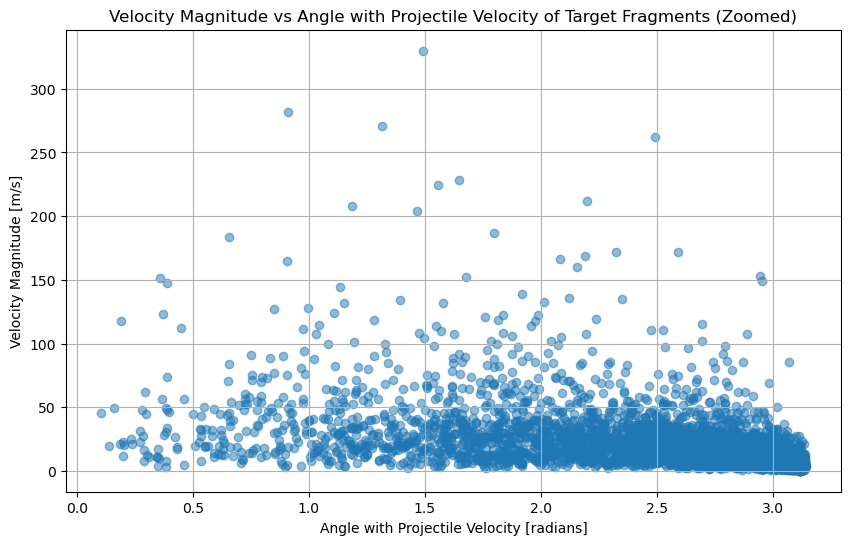

In [46]:
# Lets focus on velocities lower than 5000 m/s for the scatter vs angle with projectile velocity
velocity_magnitudes = np.linalg.norm(target_velocities, axis=1)
mask = velocity_magnitudes < 5000
plt.figure(figsize=(10, 6))
plt.scatter(angles[mask], velocity_magnitudes[mask], alpha=0.5)
plt.title("Velocity Magnitude vs Angle with Projectile Velocity of Target Fragments (Zoomed)")
plt.xlabel("Angle with Projectile Velocity [radians]")
plt.ylabel("Velocity Magnitude [m/s]")
plt.grid()
plt.show()